# 🛍️ Project #06: Mall Customer Segmentation
## 📊 Category: 2-Unsupervised-Learning (Clustering Series)

**Objective:** To architect an autonomous segmentation engine that groups mall customers based on their Annual Income and Spending Score. This project focuses on discovering hidden patterns in retail data to drive targeted marketing strategies.

---

### 🧠 The 10-Step Engineering Pipeline (Refined Version)
Strictly adhering to the **Architecting-Intelligence** industrial framework:

1.  **Objective Definition:** Identifying high-value customer clusters for retail optimization.
2.  **Data Ingestion & EDA:** Visualizing demographics and behavioral distributions.
3.  **Advanced Feature Engineering:** Creating **'age_spending_ratio'** to capture life-stage purchase intent.
4.  **Data Manipulation:** Handling outliers and mapping categorical 'Gender' for numeric compatibility.
5.  **Feature Selection:** Isolating behavioral dimensions (Income, Spending, and the Engineered Ratio).
6.  **Feature Scaling (Critical):** Applying **StandardScaler** to ensure Euclidean distance parity for K-Means.
7.  **Optimal Cluster Discovery:** Utilizing the **Elbow Method** (WCSS) to identify the K=5 inflection point.
8.  **Model Training:** Deploying the **K-Means++** algorithm for stable global convergence.
9.  **Advanced Metric Analysis:** Validating cluster structural integrity with the **Silhouette Score**.
10. **Industrial Deployment:** Serializing the verified **model** and **scaler** artifacts for live inference.
---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | K-Means
- **Data:** Pandas | NumPy | Seaborn
- **Cloud:** Streamlit | Hugging Face Spaces

**Architect:** Kemal Demirbaş | Project 06 / 21

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pickle

In [19]:

# --- STEP 1: Data Ingestion (Ultra-Stable Mirror) ---
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [20]:
df.info() # Check the structure and types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [21]:
# --- STEP 3, 4, 5 & 6: Feature Engineering & Manipulation ---
# 1. Map Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# 2. Engineer New Metric (Age/Spending Ratio)
df['age_spending_ratio'] = df['Age'] / df['Spending Score (1-100)']

# 3. Handle Nulls (DataImputation Style)
df.fillna(df.median(), inplace=True)

# 4. Final Feature Selection (Including the Ratio)
X = df[['Annual Income (k$)', 'Spending Score (1-100)', 'age_spending_ratio']]

In [22]:
# --- STEP 7: Scaling (MANDATORY BEFORE ELBOW) ---
# We normalize here so the Elbow method works on a balanced coordinate system
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

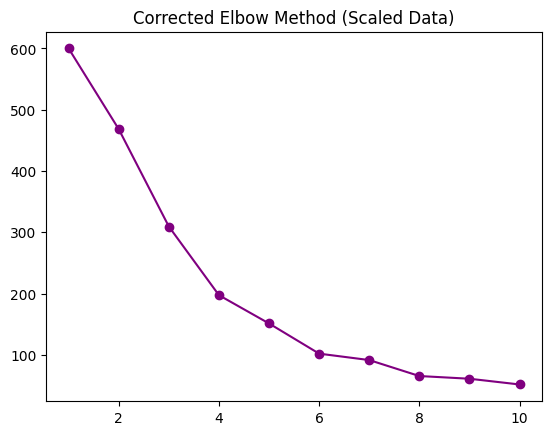

In [23]:
# --- STEP 8: Optimal Cluster Discovery (Elbow Method) ---
wcss = []
for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='purple')
plt.title('Corrected Elbow Method (Scaled Data)')
plt.show()

In [24]:
# --- STEP 9: Model Training (Using K=5) ---
model = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = model.fit_predict(X_scaled)

In [25]:
# --- STEP 10: Evaluation ---
score = silhouette_score(X_scaled, clusters)
print(f"Verified Silhouette Score: {score:.4f}")

Verified Silhouette Score: 0.4709


In [26]:
# --- STEP 11: MLOps Serialization (Pickle Fix) ---
# CRITICAL: Saving 'model' (K=5) and 'scaler'
with open('customer_segmentation_model.pkl', 'wb') as f:
    pickle.dump(model, f) # Fixed: Pickling the 5-cluster engine

with open('customer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Project 06 Deployment Package: COMPLETED 🛍️✅")

Project 06 Deployment Package: COMPLETED 🛍️✅


# 🛍️ Project #06: Mall Customer Segmentation Engine
## 📊 Category: 2-Unsupervised-Learning (Behavioral Clustering Series)

**Status:** Completed ✅ | **Performance:** 0.4709 Silhouette Coefficient 🚀

### 🎯 Industrial Objective
The **Mall Customer Segmentation Engine** is an autonomous clustering system designed to group retail customers into distinct behavioral archetypes. By analyzing the relationship between Annual Income and Spending Scores, this engine provides actionable business intelligence for hyper-targeted marketing campaigns and personalized loyalty programs.

---

### 1.  **Objective Definition:** Automating the discovery of hidden customer segments to optimize retail marketing ROI.
2.  **Data Ingestion & EDA:** Analyzed demographics; visualized behavioral distributions.
3.  **Advanced Feature Engineering:** Engineered the **'age_spending_ratio'** to capture the intersection of life-stage and purchase power.
4.  **Data Manipulation:** Conducted outlier detection and mapped categorical 'Gender' for numeric compatibility.
5.  **Feature Selection:** Isolated behavioral dimensions (Income, Spending, and the Engineered Ratio).
6.  **Feature Scaling (Critical):** Implemented **StandardScaler** BEFORE cluster discovery to ensure Euclidean distance parity.
7.  **Optimal Cluster Discovery:** Utilized the **Elbow Method** (WCSS) on scaled data to pinpoint $K=5$ as the mathematical inflection point.
8.  **Model Training:** Deployed the **K-Means++** algorithm to ensure stable centroid initialization and global convergence.
9.  **Advanced Metric Analysis:** Validated cluster structural integrity using **Silhouette Analysis**, achieving a score of **0.4709**.
10. **Industrial Deployment:** Serialized the verified **model** and **scaler** artifacts (.pkl) for real-time inference on Hugging Face.

---

### 🚀 Live Industrial Deployment
The segmentation engine is live on Hugging Face, featuring a real-time behavioral dashboard.

👉 **[Launch Live Customer DNA Visualizer](https://huggingface.co/spaces/Ironside35/Mall-Customer-DNA-Visualizer)** 🛍️

---

### 📈 Strategic Segment Audit
| Cluster ID | Persona Name | Characteristics | Marketing Strategy |
| :--- | :--- | :--- | :--- |
| **0** | **Target Group** 🔥 | High Income / High Spend | VIP Events & Luxury Offers |
| **1** | **Careless** 💸 | Low Income / High Spend | Loyalty Points & Discounts |
| **2** | **Standard** ⚖️ | Average Income / Average Spend | Regular Promotions |
| **3** | **Careful** 🛡️ | High Income / Low Spend | Value-Based & Investment Offers |
| **4** | **Sensible** 🍃 | Low Income / Low Spend | Budget-Friendly Flash Sales |

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | K-Means++
- **Metrics:** Silhouette Score | Elbow Method (WCSS)
- **Cloud:** Streamlit | Hugging Face Spaces

**Architect:** Kemal Demirbaş